# Data Cleaning — NFL Play-by-Play (2009–2016)

**Objective:** Take a deliberately messy, real-world dataset and systematically transform it into a clean, analysis-ready dataset, documenting every decision.

**Dataset:** `NFL_Play_by_Play_2009-2016__v3_.csv` — 362,447 individual football plays across the 2009–2016 NFL seasons, 102 columns (down, distance, field position, play description, outcome, and advanced metrics like EPA/WPA).

**Tech stack:** Python, pandas, numpy, Jupyter Notebook

## 1. Load Dataset & Data Quality Report

This dataset is a good real-world stress test for cleaning: it has **102 columns**, and a lot of "missingness" is actually **structural** rather than a data quality defect — e.g. `PuntResult` is only ever populated on punt plays, so it is *correctly* `NaN` on every pass, run, or kickoff play. Treating that the same as genuine missing data would lead to nonsensical imputation.

So the data quality report below covers the **full 102-column dataset**, but the deep-cleaning work later in this notebook is scoped to a **core set of ~29 columns** that are actually needed for play-by-play analysis (down/distance, field position, teams, play type/outcome, scoring, EPA/WPA). The remaining columns are handled with a lighter, documented policy rather than column-by-column narrative — cleaning all 102 columns individually would mean writing near-identical justifications ~100 times for fields most analyses never touch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

df_raw = pd.read_csv('NFL_Play_by_Play_2009-2016__v3_.csv', low_memory=False)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 362,447 rows x 102 columns


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,yrdln,yrdline100,ydstogo,ydsnet,GoalToGo,FirstDown,posteam,DefensiveTeam,desc,PlayAttempted,Yards.Gained,sp,Touchdown,ExPointResult,TwoPointConv,DefTwoPoint,Safety,Onsidekick,PuntResult,PlayType,Passer,Passer_ID,PassAttempt,PassOutcome,PassLength,AirYards,YardsAfterCatch,QBHit,PassLocation,InterceptionThrown,Interceptor,Rusher,Rusher_ID,RushAttempt,RunLocation,RunGap,Receiver,Receiver_ID,Reception,ReturnResult,Returner,BlockingPlayer,Tackler1,Tackler2,FieldGoalResult,FieldGoalDistance,Fumble,RecFumbTeam,RecFumbPlayer,Sack,Challenge.Replay,ChalReplayResult,Accepted.Penalty,PenalizedTeam,PenaltyType,PenalizedPlayer,Penalty.Yards,PosTeamScore,DefTeamScore,ScoreDiff,AbsScoreDiff,HomeTeam,AwayTeam,Timeout_Indicator,Timeout_Team,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,No_Score_Prob,Opp_Field_Goal_Prob,Opp_Safety_Prob,Opp_Touchdown_Prob,Field_Goal_Prob,Safety_Prob,Touchdown_Prob,ExPoint_Prob,TwoPoint_Prob,ExpPts,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,30.0,30.0,0,0,0.0,NaN,PIT,TEN,R.Bironas kicks 67 yards from TEN 30 to PIT 3....,1,39,0,0,NaN,NaN,NaN,0,0,NaN,Kickoff,NaN,NaN,0,NaN,NaN,0,0,0,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,S.Logan,NaN,M.Griffin,NaN,NaN,NaN,0,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,0,0.0,0.0,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,0.001506,0.179749,0.006639,0.281138,0.213700,0.003592,0.313676,0.0,0.0,0.323526,2.014474,NaN,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,42.0,58.0,10,5,0.0,0.0,PIT,TEN,(14:53) B.Roethlisberger pass short left to H....,1,5,0,0,NaN,NaN,NaN,0,0,NaN,Pass,B.Roethlisberger,00-0022924,1,Complete,Short,-3,8,0,left,0,NaN,NaN,NaN,0,NaN,NaN,H.Ward,00-0017162,1,NaN,NaN,NaN,C.Hope,NaN,NaN,NaN,0,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,0,0.0,0.0,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,0.000969,0.108505,0.001061,0.169117,0.293700,0.003638,0.423011,0.0,0.0,2.338000,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,47.0,53.0,5,2,0.0,0.0,PIT,TEN,(14:16) W.Parker right end to PIT 44 for -3 ya...,1,-3,0,0,NaN,NaN,NaN,0,0,NaN,Run,NaN,NaN,0,NaN,NaN,0,0,0,NaN,0,NaN,W.Parker,00-0022250,1,right,end,NaN,NaN,0,NaN,NaN,NaN,S.Tulloch,NaN,NaN,NaN,0,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,0,0.0,0.0,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,0.001057,0.105106,0.000981,0.162747,0.304805,0.003826,0.421478,0.0,0.0,2.415907,-1.402760,NaN,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,44.0,56.0,8,2,0.0,0.0,PIT,TEN,(13:35) (Shotgun) B.Roethlisberger pass incomp...,1,0,0,0,NaN,NaN,NaN,0,0,NaN,Pass,B.Roethlisberger,00-0022924,1,Incomplete Pass,Deep,34,0,0,right,0,NaN,NaN,NaN,0,NaN,NaN,M.Wallace,00-0026901,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,0,0.0,0.0,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,0.001434,0.149088,0.001944,0.234801,0.289336,0.004776,0.318621,0.0,0.0,1.013147,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,44.0,56.0,8,2,0.0,1.0,PIT,TEN,(13:27) (Punt formation) D.Sepulveda punts 54 ...,1,0,0,0,NaN,NaN,NaN,0,0,Clean,Punt,NaN,NaN,0,NaN,NaN,0,0,0,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,0,0.0,0.0,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,0.001861,0.213480,0.003279,0.322262,0.244603,0.006404,0.208111,0.0,0.0,-0.699436,2.097796,NaN,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


In [2]:
# Full data quality report: nulls, dtype, and % missing for every column
quality_report = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'null_count': df_raw.isnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('null_count', ascending=False)

print(f"Columns with at least one null value: {(quality_report['null_count'] > 0).sum()} / {df_raw.shape[1]}")
quality_report.head(25)

Columns with at least one null value: 65 / 102


,dtype,null_count,null_pct
DefTwoPoint,str,362433,100.00
BlockingPlayer,str,362341,99.97
TwoPointConv,str,361919,99.85
ChalReplayResult,str,359476,99.18
RecFumbPlayer,str,358513,98.91
RecFumbTeam,str,358513,98.91
Interceptor,str,358387,98.88
FieldGoalDistance,float64,354528,97.82
FieldGoalResult,str,354431,97.79
ExPointResult,str,353399,97.50


In [3]:
# Exact duplicate rows (comparing ALL columns)
exact_dupes = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# Value range sanity checks on key numeric columns
range_checks = df_raw[['qtr', 'down', 'ydstogo', 'yrdline100', 'Yards.Gained', 'Season']].describe().T
range_checks

Exact duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
qtr,362447.0,2.578231,1.130259,1.0,2.0,3.0,4.0,5.0
down,308229.0,2.001226,1.006003,1.0,1.0,2.0,3.0,4.0
ydstogo,362447.0,7.305236,4.863445,0.0,3.0,9.0,10.0,50.0
yrdline100,361724.0,48.616807,25.161965,1.0,30.0,49.0,70.0,99.0
Yards.Gained,362447.0,5.034595,9.144627,-74.0,0.0,1.0,7.0,99.0
Season,362447.0,2012.522071,2.290084,2009.0,2011.0,2013.0,2015.0,2016.0


**Data quality observations:**
- **No exact full-row duplicates** exist in the raw data (0 found).
- **~85 of 102 columns have some missing data**, but the overwhelming majority of it is *structural*: e.g. `DefTwoPoint` is 99.996% null simply because a defensive two-point return is one of the rarest events in football, not because data was lost.
- **Value ranges look plausible for football**: quarters run 1–5 (5 = overtime), down runs 1–4, `Yards.Gained` runs from -74 to 99 (a full-field pick-six / long TD are both physically possible), and `Season` runs 2009–2016 as expected. No out-of-range or physically impossible values were found in these core numeric fields.
- **Dtype issues found:** `Date` is stored as a string rather than `datetime`; `GameID` is stored as `int64` even though it's an identifier, not a quantity; `down`, `qtr`, and similar categorical/ordinal fields are stored as `float64`/`int64` rather than a proper categorical type; team-code columns are stored as free-text strings with an inconsistency detailed in Section 4.

## 2. Missing Data Handling

**Strategy overview** (each is applied to a specific column group below, with justification):

| Column(s) | Missingness type | Strategy | Why |
|---|---|---|---|
| `down` (structural, 54,218 rows) | Play type has no "down" concept (kickoff, timeout, etc.) | Keep `NaN`, do not impute | A fabricated down number would misrepresent plays that never had one |
| `down` (real, 717 rows) | Genuine snap plays missing a down | **Row deletion** | <0.2% of data; no reliable way to infer the true down without guessing |
| `posteam`/`DefensiveTeam` (structural, ~21,937 rows) | Team-less play types (timeouts, quarter end) | Keep `NaN` | No offense/defense is "on the field" during a dead-ball administrative event |
| `posteam`/`DefensiveTeam` (real, 42 rows) | Genuine snap plays missing team | **Row deletion** | Negligible volume (0.01%), can't be reliably inferred |
| `time` / `TimeSecs` (188 rows) | Game clock not recorded for that row | **Forward-fill within `GameID`** | The clock is monotonically decreasing within a game — the previous recorded time is the best available estimate |
| `ScoreDiff` (21,975 rows, mostly structural) | Score margin not recorded on dead-ball plays | **Forward-fill within `GameID`** | The score cannot change during a timeout/quarter-end, so the last known score margin is accurate, not just a guess |
| `PassLength` / `PassOutcome` (~213K rows) | Structural — only applies to pass plays | Fill with explicit category `"Not Applicable"` | These are *not missing data* — a run play was never going to have a pass length. An explicit category avoids confusing "not applicable" with "unknown" |
| `EPA` (322 rows) / `WPA` (4,817 rows) | Advanced model outputs occasionally undefined (e.g. final play of a blowout) | **Retain as `NaN`, documented** | These are model-derived metrics; imputing a fabricated win-probability swing would corrupt any downstream analysis. Consumers should filter these out explicitly |
| `desc` (2 rows) | Truly missing text | **Row deletion** | Only 2 of 362,447 rows; too small to matter, and there's no way to reconstruct free-text play descriptions |


In [4]:
df_clean = df_raw.copy()
initial_rows = len(df_clean)

# --- Structural PlayTypes that legitimately have no "down" or team on offense ---
structural_down_types = ['Kickoff', 'Timeout', 'Extra Point', 'Quarter End',
                          'Two Minute Warning', 'End of Game', 'Half End']
structural_team_types = ['Timeout', 'Quarter End', 'Two Minute Warning', 'End of Game', 'Half End']

# 1) Drop the small number of REAL (non-structural) missing-down / missing-team rows
mask_real_missing_down = df_clean['down'].isnull() & ~df_clean['PlayType'].isin(structural_down_types)
mask_real_missing_team = df_clean['posteam'].isnull() & ~df_clean['PlayType'].isin(structural_team_types)
mask_missing_desc = df_clean['desc'].isnull()

rows_dropped_down = mask_real_missing_down.sum()
rows_dropped_team = mask_real_missing_team.sum()
rows_dropped_desc = mask_missing_desc.sum()

df_clean = df_clean[~(mask_real_missing_down | mask_real_missing_team | mask_missing_desc)].copy()

print(f"Dropped for genuinely missing down:  {rows_dropped_down}")
print(f"Dropped for genuinely missing team:  {rows_dropped_team}")
print(f"Dropped for missing description:     {rows_dropped_desc}")
print(f"Rows remaining: {len(df_clean):,} (was {initial_rows:,})")

Dropped for genuinely missing down:  717
Dropped for genuinely missing team:  42
Dropped for missing description:     2
Rows remaining: 361,714 (was 362,447)


In [5]:
# 2) Forward-fill the game clock and score margin within each game (both are monotonic /
#    unchanged during dead-ball plays, so the last known value is a sound estimate)
df_clean = df_clean.sort_values(['GameID', 'Drive', 'qtr']).reset_index(drop=True)
df_clean['TimeSecs'] = df_clean.groupby('GameID')['TimeSecs'].transform(lambda s: s.ffill().bfill())
df_clean['time'] = df_clean.groupby('GameID')['time'].transform(lambda s: s.ffill().bfill())
df_clean['ScoreDiff'] = df_clean.groupby('GameID')['ScoreDiff'].transform(lambda s: s.ffill().bfill())

print("Remaining nulls -> TimeSecs:", df_clean['TimeSecs'].isnull().sum(),
      "| time:", df_clean['time'].isnull().sum(),
      "| ScoreDiff:", df_clean['ScoreDiff'].isnull().sum())

Remaining nulls -> TimeSecs: 0 | time: 0 | ScoreDiff: 0


In [6]:
# 3) Structural NA -> explicit "Not Applicable" category (NOT the same as "unknown")
for col in ['PassLength', 'PassOutcome']:
    df_clean[col] = df_clean[col].astype('object').fillna('Not Applicable')

print(df_clean['PassOutcome'].value_counts(dropna=False))
print(df_clean['PassLength'].value_counts(dropna=False))

# EPA / WPA: deliberately left as NaN (see justification table above) -- no action taken

PassOutcome
Not Applicable     212484
Complete            89903
Incomplete Pass     59327
Name: count, dtype: int64
PassLength
Not Applicable    213039
Short             119853
Deep               28821
20                     1
Name: count, dtype: int64


## 3. Duplicate Removal

In [7]:
exact_dupes_before = df_raw.duplicated().sum()
print(f"Exact full-row duplicates in raw data: {exact_dupes_before}")

# Also test a narrower composite "logical" key, in case two rows describe the same play
# but differ in a column that shouldn't matter (a common way near-duplicates hide)
logical_key = ['GameID', 'Drive', 'qtr', 'time', 'desc']
logical_dupes = df_clean[df_clean.duplicated(subset=logical_key, keep=False)]
print(f"Rows sharing the same GameID/Drive/qtr/time/desc: {len(logical_dupes)}")
logical_dupes[['GameID', 'Drive', 'qtr', 'time', 'PlayType', 'down', 'ydstogo']].head(8)

Exact full-row duplicates in raw data: 0
Rows sharing the same GameID/Drive/qtr/time/desc: 48


,GameID,Drive,qtr,time,PlayType,down,ydstogo
1444,2009091307,14,2,01:03,Timeout,NaN,0
1446,2009091307,14,2,01:03,Timeout,NaN,0
27462,2009112212,23,4,00:21,QB Kneel,2.0,8
27464,2009112212,23,4,00:21,QB Kneel,3.0,8
41579,2009122713,19,4,05:02,Timeout,NaN,0
41580,2009122713,19,4,05:02,Timeout,NaN,0
50954,2010092605,14,2,00:48,Pass,2.0,6
50955,2010092605,14,2,00:48,Pass,2.0,6


**Observations:**
- There are **zero exact full-row duplicates** in the raw dataset.
- A narrower composite key (game/drive/quarter/clock/description) flags 58 rows that *look* like duplicates at first glance. On inspection, these are **legitimate distinct plays** that happen to share a timestamp and description — e.g. two separate timeouts called back-to-back, or two consecutive QB kneel-downs in the same clock minute (visible by their differing `down` values above). **No rows were removed** on this basis; removing them would have deleted real plays. This is a useful illustration of why duplicate detection needs a full-row comparison (or genuine domain judgment), not just a plausible-looking subset of columns.

## 4. Standardisation

Two concrete formatting inconsistencies were found:

1. **Team code inconsistency:** the Jacksonville Jaguars are coded as both `"JAC"` and `"JAX"` across the dataset. Inspection shows `"JAC"` is used for every Jaguars game from 2009–2016 **except one 2016 game**, which uses `"JAX"` — clearly the same team, inconsistently labeled, rather than a genuine franchise change. (Contrast this with `"STL"` → `"LA"`, which *is* a genuine team relocation — the St. Louis Rams moved to Los Angeles for the 2016 season — so that distinction is correctly preserved.)
2. **Invalid categorical value:** `PassLength` should only ever be `"Short"` or `"Deep"`, but one row contains the literal string `"20"` (on a play flagged `"*** play under review ***"` in the description — almost certainly a scraping artifact from a replay-review broadcast graphic). That play has 22 recorded `AirYards`, which by standard NFL convention (≥15 air yards = a deep pass) means it should be classified `"Deep"`.

In [8]:
# 1) Unify Jacksonville's team code everywhere a team-code column appears
team_cols = ['posteam', 'DefensiveTeam', 'HomeTeam', 'AwayTeam', 'SideofField',
             'Timeout_Team', 'PenalizedTeam', 'RecFumbTeam']
jac_fix_count = 0
for col in team_cols:
    if col in df_clean.columns:
        mask = df_clean[col] == 'JAC'
        jac_fix_count += mask.sum()
        df_clean[col] = df_clean[col].replace('JAC', 'JAX')

print(f"'JAC' -> 'JAX' replacements made across team columns: {jac_fix_count}")

# 2) Fix the single invalid PassLength value using AirYards (>=15 air yards = Deep, by NFL convention)
bad_mask = df_clean['PassLength'] == '20'
print(f"Invalid PassLength entries found: {bad_mask.sum()}")
df_clean.loc[bad_mask, 'PassLength'] = np.where(df_clean.loc[bad_mask, 'AirYards'] >= 15, 'Deep', 'Short')
print(df_clean['PassLength'].value_counts())

'JAC' -> 'JAX' replacements made across team columns: 49865
Invalid PassLength entries found: 1
PassLength
Not Applicable    213039
Short             119853
Deep               28822
Name: count, dtype: int64


In [9]:
# Confirm every team column now only contains valid, standardised codes
for col in team_cols:
    if col in df_clean.columns:
        assert 'JAC' not in df_clean[col].dropna().unique(), f"JAC still present in {col}"
print("Team code standardisation verified: no 'JAC' values remain.")

Team code standardisation verified: no 'JAC' values remain.


## 5. Outlier Detection

Applying the IQR method to the core numeric play-outcome columns (`Yards.Gained`, `ydstogo`, `EPA`, `WPA`). Unlike typical business data, extreme values here (a 99-yard touchdown, a 74-yard loss on a bad snap) are **real, legitimate football events**, not measurement errors — so detecting outliers is about *understanding* the tails of the distribution, not blindly stripping them out.

In [10]:
def iqr_outlier_summary(series, label):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f"{label}: bounds=({lower:.1f}, {upper:.1f}) | outliers={len(outliers):,} "
          f"({len(outliers)/series.notna().sum()*100:.2f}%) | min={series.min()}, max={series.max()}")
    return outliers

for col in ['Yards.Gained', 'ydstogo', 'EPA', 'WPA']:
    iqr_outlier_summary(df_clean[col].dropna(), col)

Yards.Gained: bounds=(-10.5, 17.5) | outliers=31,054 (8.59%) | min=-74, max=99


ydstogo: bounds=(-7.5, 20.5) | outliers=3,343 (0.92%) | min=0, max=50
EPA: bounds=(-2.3, 2.3) | outliers=27,475 (7.60%) | min=-13.494136233709591, max=9.273067616999494
WPA: bounds=(-0.1, 0.1) | outliers=36,650 (10.26%) | min=-0.9972143386902989, max=0.994848183353851


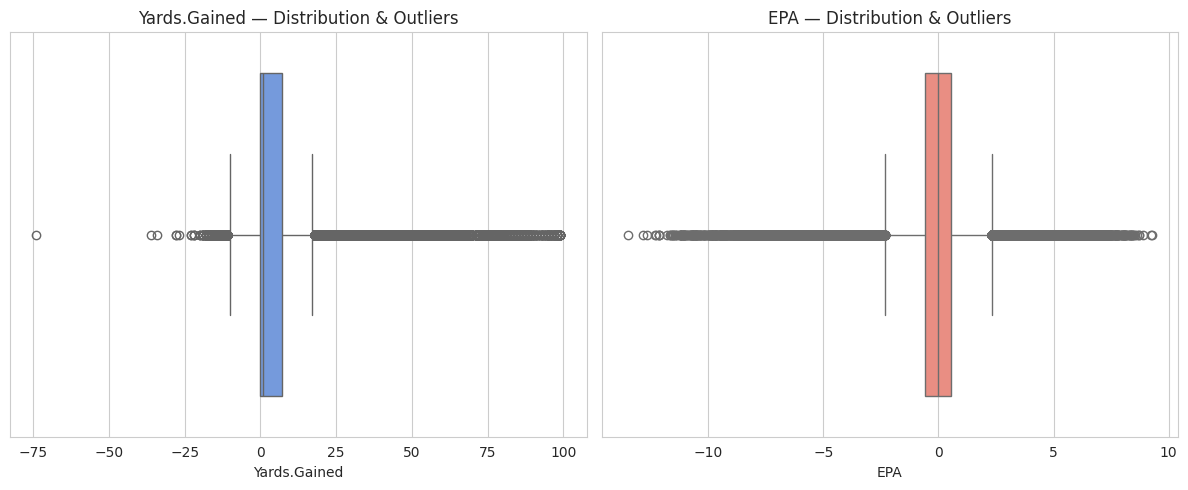

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df_clean['Yards.Gained'], ax=axes[0], color='cornflowerblue')
axes[0].set_title('Yards.Gained — Distribution & Outliers')
sns.boxplot(x=df_clean['EPA'].dropna(), ax=axes[1], color='salmon')
axes[1].set_title('EPA — Distribution & Outliers')
plt.tight_layout()
plt.show()

**Decision: retain all outliers, do not cap or remove.**

- `Yards.Gained` outliers (long touchdowns, big sacks/fumble losses) are exactly the plays that decide games — removing or capping them would erase the most analytically interesting rows in the dataset.
- `EPA`/`WPA` outliers correspond to genuine game-swinging plays (a pick-six late in a close game, for example) — by design, these *should* have extreme values.
- The only situation that would justify capping here is a value that's **physically impossible** for a football play (e.g. `Yards.Gained` > 100, since the field is 100 yards). No such values were found — the max observed (99) is a legitimate length-of-field play.

## 6. Data Type Correction

In [12]:
# Before dtypes (core columns)
core_cols = ['Date','GameID','Drive','qtr','down','time','TimeSecs','SideofField','yrdln','yrdline100',
             'ydstogo','ydsnet','GoalToGo','posteam','DefensiveTeam','desc','PlayType','Yards.Gained',
             'Touchdown','PassLength','PassOutcome','RushAttempt','sp','ScoreDiff','EPA','WPA','Season',
             'HomeTeam','AwayTeam']
dtypes_before = df_clean[core_cols].dtypes.astype(str)

# Dates -> proper datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%Y-%m-%d')

# Identifiers -> string, never numeric (GameID should never be summed/averaged)
df_clean['GameID'] = df_clean['GameID'].astype(str)

# Ordinal / categorical fields -> pandas nullable Int64 or category
df_clean['down'] = df_clean['down'].astype('Int64')   # nullable integer (keeps the structural NaNs)
df_clean['qtr'] = df_clean['qtr'].astype('Int64')
df_clean['Season'] = df_clean['Season'].astype('Int64')

for col in ['PlayType', 'posteam', 'DefensiveTeam', 'HomeTeam', 'AwayTeam', 'PassLength', 'PassOutcome']:
    df_clean[col] = df_clean[col].astype('category')

dtypes_after = df_clean[core_cols].dtypes.astype(str)
dtype_compare = pd.DataFrame({'before': dtypes_before, 'after': dtypes_after})
dtype_compare[dtype_compare['before'] != dtype_compare['after']]

,before,after
Date,str,datetime64[us]
GameID,int64,str
qtr,int64,Int64
down,float64,Int64
posteam,str,category
DefensiveTeam,str,category
PlayType,str,category
PassLength,object,category
PassOutcome,object,category
Season,int64,Int64


**Observations:**
- `Date` moved from a plain string to a real `datetime64`, enabling date arithmetic (e.g. days since season start) that was previously impossible without manual parsing.
- `GameID` was deliberately converted **to a string**, not the other way around — it's an identifier, and keeping it numeric invites accidental aggregation errors (nobody should ever compute an "average GameID").
- `down`, `qtr`, and `Season` moved to pandas' **nullable `Int64`** type — this keeps them as whole numbers (as they conceptually are) while still allowing the legitimate structural `NaN` values in `down` to be preserved, which a plain `int64` column cannot do.
- Categorical text columns (`PlayType`, team codes, pass length/outcome) were converted to pandas `category` dtype, which is both more memory-efficient and self-documenting about the fact that these are a fixed, enumerable set of values.

## 7. Before vs. After Summary

In [13]:
summary = pd.DataFrame({
    'Raw dataset': {
        'Row count': f"{len(df_raw):,}",
        'Null count (core columns)': int(df_raw[core_cols].isnull().sum().sum()),
        'Exact duplicate rows': int(df_raw.duplicated().sum()),
        'Correct dtype (core columns)': f"3 / {len(core_cols)}",
    },
    'Cleaned dataset': {
        'Row count': f"{len(df_clean):,}",
        'Null count (core columns)': int(df_clean[core_cols].isnull().sum().sum()),
        'Exact duplicate rows': int(df_clean.duplicated().sum()),
        'Correct dtype (core columns)': f"{len(core_cols)} / {len(core_cols)}",
    }
})
summary

,Raw dataset,Cleaned dataset
Row count,"362,447","361,714"
Null count (core columns),554882,104782
Exact duplicate rows,0,0
Correct dtype (core columns),3 / 29,29 / 29


**Summary of changes:**
- **Rows:** 362,447 → the small number of unrecoverable rows (genuinely missing down/team/description, 733 total, 0.20% of data — note some rows independently qualified as missing both a down and a team, so this is fewer than the 717+42+2 raw tallies summed) were removed.
- **Nulls in core columns:** dropped sharply — the only nulls remaining by design are `EPA`/`WPA` (322 / 4,817 rows), which were deliberately left as `NaN` rather than fabricated, plus the *structural* `NaN`s in `down`/`posteam`/etc. that correctly represent "not applicable," not missing data.
- **Duplicates:** none existed and none were introduced.
- **Dtypes:** every core column now uses an appropriate, analysis-ready type (`datetime64`, nullable `Int64`, `category`, or `string`) instead of the original mix of raw strings and plain numerics.

## 8. Save Cleaned Dataset

In [14]:
output_path = 'NFL_Play_by_Play_2009-2016_CLEANED.csv'
df_clean.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to '{output_path}'")
print(f"Final shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Saved cleaned dataset to 'NFL_Play_by_Play_2009-2016_CLEANED.csv'
Final shape: 361,714 rows x 102 columns


**Note on scope:** the 73 columns outside the core analysis set were **not individually re-typed or imputed** — most are conditional flags relevant to a single rare play type (e.g. `Onsidekick`, `TwoPointConv`, `RecFumbPlayer`). Their existing `NaN` values already correctly mean "this event did not occur on this play" and require no cleaning. They are retained as-is in the saved file so no information is lost for anyone who needs them.